**_Copyright Notice_**

This notebook is available for educational purposes. You may not use or distribute this notebook for commercial purposes. You may make copies of this notebook and use or distribute it for educational purposes as long as you cite the author as the source of the notebook.

Jaeyoung Chun | School of Applied Artificial Intelligence | Handong Global University

# Predict

Process: Features → λ → Poisson → Outcome Probabilities

In [1]:
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import poisson

## Load

In [2]:
df = pd.read_parquet("./intermediate/final.parquet")

In [3]:
df

,date,home_team,away_team,goals_scored_home,goals_avg_home,goals_avg_lastn_home,goals_suf_avg_home,goals_suf_avg_lastn_home,rank_avg_home,rank_avg_lastn_home,...,goals_avg_lastn_diff,goals_suf_avg_diff,goals_suf_avg_lastn_diff,rank_avg_diff,rank_avg_lastn_diff,points_avg_diff,points_avg_lastn_diff,rank_home,rank_away,rank_diff
0,2018-08-26,Barbados,Cuba,0,2.000000,2.0,2.000000,2.0,54.000000,54.0,...,2.0,1.000000,1.0,-92.000000,-92.0,65.000000,65.000,160,181,-21
1,2018-08-29,Barbados,Cuba,0,1.000000,1.0,1.000000,1.0,117.500000,117.5,...,1.0,0.500000,0.5,-35.500000,-35.5,65.000000,65.000,160,181,-21
2,2018-09-06,Mongolia,Guam,1,4.000000,4.0,1.000000,1.0,185.000000,185.0,...,4.0,-1.000000,-1.0,0.000000,0.0,8.000000,8.000,186,190,-4
3,2018-09-06,Nepal,Bhutan,4,1.000000,1.0,2.000000,2.0,201.000000,201.0,...,1.0,0.000000,0.0,7.000000,7.0,72.000000,72.000,161,183,-22
4,2018-09-06,Bangladesh,Pakistan,1,1.000000,1.0,0.500000,0.5,191.500000,191.5,...,-1.0,-0.500000,-0.5,30.500000,30.5,20.000000,20.000,194,201,-7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3275,2022-09-27,Norway,Serbia,0,1.761905,1.4,0.880952,1.0,63.547619,38.6,...,-0.8,-0.230159,0.0,9.014286,-3.4,-54.433571,-79.416,36,25,11
3276,2022-09-27,Sweden,Slovenia,1,1.411765,1.2,1.137255,2.0,51.254902,39.4,...,0.2,0.137255,0.2,-25.102241,10.2,199.336008,203.424,20,65,-45
3277,2022-09-27,Kosovo,Cyprus,5,1.434783,1.2,1.304348,1.4,77.456522,65.4,...,0.6,-0.463094,0.0,7.037917,1.6,-85.712599,-9.076,106,108,-2
3278,2022-09-27,Greece,Northern Ireland,3,1.090909,1.4,0.909091,0.2,73.931818,96.2,...,0.2,-0.369979,-1.2,16.024841,0.6,-34.891411,6.774,49,58,-9


## Stats for World Cup 2022 Teams

In [4]:
# FIFA World Cup 2022 participants (32 teams)
worldcup_teams = [
    'Qatar', 'Ecuador', 'Senegal', 'Netherlands',       # Group A
    'England', 'Iran', 'United States', 'Wales',        # Group B
    'Argentina', 'Saudi Arabia', 'Mexico', 'Poland',    # Group C
    'France', 'Australia', 'Denmark', 'Tunisia',        # Group D
    'Spain', 'Costa Rica', 'Germany', 'Japan',          # Group E
    'Belgium', 'Canada', 'Morocco', 'Croatia',          # Group F
    'Brazil', 'Serbia', 'Switzerland', 'Cameroon',      # Group G
    'Portugal', 'Ghana', 'Uruguay', 'South Korea'       # Group H
]

In [5]:
# FIFA World Cup 2022 start date = 2022-11-20
# we will look at the data up to this date
cutoff_date = pd.Timestamp('2022-11-20')

In [6]:
team_hist = df[
    (df.home_team == "South Korea") & (df['date'] < cutoff_date)
].sort_values('date')

In [7]:
team_hist

,date,home_team,away_team,goals_scored_home,goals_avg_home,goals_avg_lastn_home,goals_suf_avg_home,goals_suf_avg_lastn_home,rank_avg_home,rank_avg_lastn_home,...,goals_avg_lastn_diff,goals_suf_avg_diff,goals_suf_avg_lastn_diff,rank_avg_diff,rank_avg_lastn_diff,points_avg_diff,points_avg_lastn_diff,rank_home,rank_away,rank_diff
74,2018-10-12,South Korea,Uruguay,2,1.000000,1.000000,0.000000,0.000000,22.000000,22.000000,...,-3.000000,-1.000000,-1.000000,6.000000,6.000000,-240.000000,-240.000000,55,5,50
143,2018-10-16,South Korea,Panama,2,1.333333,1.333333,0.333333,0.333333,16.333333,16.333333,...,1.333333,-2.166667,-2.166667,-26.166667,-26.166667,48.666667,48.666667,55,70,-15
284,2018-11-20,South Korea,Uzbekistan,4,1.400000,1.400000,0.800000,0.800000,32.200000,32.200000,...,0.650000,0.300000,0.300000,-38.050000,-38.050000,144.750000,144.750000,53,94,-41
318,2018-12-31,South Korea,Saudi Arabia,0,1.833333,1.800000,0.666667,0.800000,42.500000,44.600000,...,0.800000,-0.533333,-0.400000,-36.300000,-34.200000,58.733333,60.200000,53,69,-16
326,2019-01-07,South Korea,Philippines,1,1.571429,1.800000,0.571429,0.800000,46.285714,56.000000,...,0.800000,-0.873016,-1.000000,-79.825397,-60.200000,223.523810,226.400000,53,116,-63
358,2019-01-22,South Korea,Bahrain,2,1.500000,1.600000,0.500000,0.600000,55.000000,78.200000,...,0.000000,-0.277778,0.200000,-45.666667,-20.800000,217.666667,223.400000,53,113,-60
361,2019-01-25,South Korea,Qatar,0,1.555556,1.600000,0.555556,0.400000,61.444444,86.800000,...,0.400000,-0.353535,-0.200000,-5.828283,20.000000,145.707071,145.400000,53,93,-40
397,2019-03-22,South Korea,Bolivia,1,1.400000,1.400000,0.600000,0.400000,64.600000,97.000000,...,0.200000,-0.400000,-0.400000,-25.233333,3.200000,21.933333,27.800000,38,60,-22
473,2019-03-26,South Korea,Colombia,2,1.363636,0.800000,0.545455,0.400000,64.181818,90.200000,...,-1.200000,-0.254545,-0.400000,38.581818,64.600000,-163.636364,-152.800000,38,12,26
549,2019-06-07,South Korea,Australia,1,1.416667,1.200000,0.583333,0.600000,59.833333,78.800000,...,0.000000,0.027778,-0.200000,-32.611111,-12.400000,-27.222222,-12.600000,37,41,-4


In [8]:
# South Korea's most recent stats right before 2022 World Cup begins
team_hist.iloc[-1]

date                        2022-09-27 00:00:00
home_team                           South Korea
away_team                              Cameroon
goals_scored_home                             1
goals_avg_home                         1.869565
goals_avg_lastn_home                        2.2
goals_suf_avg_home                     0.826087
goals_suf_avg_lastn_home                    1.6
rank_avg_home                         70.282609
rank_avg_lastn_home                        57.0
points_avg_home                     1466.476739
points_avg_lastn_home                    1523.5
goals_scored_away                             0
goals_avg_away                         1.314286
goals_avg_lastn_away                        1.2
goals_suf_avg_away                          0.6
goals_suf_avg_lastn_away                    1.4
rank_avg_away                         90.057143
rank_avg_lastn_away                        72.4
points_avg_away                     1421.619714
points_avg_lastn_away                  1

In [9]:
team_feats = {}

for team in worldcup_teams:
    
    team_hist = df[ (df.home_team == team) & (df['date'] < cutoff_date) ].sort_values('date')
    last_stats = team_hist.iloc[-1]
    feats = {
        'goals_avg': last_stats['goals_avg_home'],
        'goals_suf_avg': last_stats['goals_avg_diff'],
        'rank_avg': last_stats['rank_avg_home'],
        'points_avg': last_stats['points_avg_home'],
        'goals_avg_lastn': last_stats['goals_avg_lastn_home'],
        'goals_suf_avg_lastn': last_stats['goals_suf_avg_lastn_home'],
        'rank_avg_lastn': last_stats['rank_avg_lastn_home'],
        'points_avg_lastn': last_stats['points_avg_lastn_home'],
    }
    team_feats[team] = feats

In [10]:
team_feats

{'Qatar': {'goals_avg': np.float64(1.6440677966101696),
  'goals_suf_avg': np.float64(0.6232344632768363),
  'rank_avg': np.float64(72.67796610169492),
  'points_avg': np.float64(1372.2545762711866),
  'goals_avg_lastn': np.float64(0.6),
  'goals_suf_avg_lastn': np.float64(1.0),
  'rank_avg_lastn': np.float64(51.0),
  'points_avg_lastn': np.float64(1435.962)},
 'Ecuador': {'goals_avg': np.float64(1.3404255319148937),
  'goals_suf_avg': np.float64(-0.9304078014184398),
  'rank_avg': np.float64(36.148936170212764),
  'points_avg': np.float64(1401.2436170212766),
  'goals_avg_lastn': np.float64(0.6),
  'goals_suf_avg_lastn': np.float64(0.8),
  'rank_avg_lastn': np.float64(29.2),
  'points_avg_lastn': np.float64(1457.252)},
 'Senegal': {'goals_avg': np.float64(1.5555555555555556),
  'goals_suf_avg': np.float64(0.27555555555555555),
  'rank_avg': np.float64(96.31111111111112),
  'points_avg': np.float64(1541.389111111111),
  'goals_avg_lastn': np.float64(1.0),
  'goals_suf_avg_lastn': np.fl

## FIFA Rankings (pre-World Cup 2022)

In [11]:
rows = []

for team in worldcup_teams:
    team_hist = df[ (df.home_team == team) & (df["date"] < cutoff_date) ].sort_values("date")
    rows.append((team, team_hist.iloc[-1].rank_home))

In [12]:
# dataframe for FIFA ranking
df_fifa_rank = pd.DataFrame(rows, columns=["country", "rank"]).set_index("rank").sort_index()

In [13]:
df_fifa_rank

,country
rank,
1,Brazil
2,Belgium
3,Argentina
4,France
5,England
6,Spain
8,Netherlands
9,Portugal
10,Denmark


In [14]:
# dictionary for FIFA ranking
worldcup_ranks = { row.country:row.Index for row in df_fifa_rank.itertuples()}

In [15]:
worldcup_ranks

{'Brazil': 1,
 'Belgium': 2,
 'Argentina': 3,
 'France': 4,
 'England': 5,
 'Spain': 6,
 'Netherlands': 8,
 'Portugal': 9,
 'Denmark': 10,
 'Germany': 11,
 'Mexico': 12,
 'Uruguay': 13,
 'United States': 15,
 'Croatia': 15,
 'Switzerland': 16,
 'Senegal': 18,
 'Wales': 19,
 'Iran': 22,
 'Morocco': 23,
 'Japan': 24,
 'Serbia': 25,
 'Poland': 26,
 'South Korea': 28,
 'Costa Rica': 34,
 'Tunisia': 35,
 'Cameroon': 38,
 'Australia': 39,
 'Canada': 43,
 'Ecuador': 44,
 'Qatar': 48,
 'Saudi Arabia': 53,
 'Ghana': 60}

## Load ML Models

In [16]:
with open("./intermediate/models.pickle", "rb") as fin:
    models = pickle.load(fin)

In [17]:
models

{'home': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...),
 'away': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=Tr

In [18]:
model_home = models["home"]
model_away = models["away"]
col_features = models["col_features"]

## Make Input Features

In [19]:
team_home = "South Korea"
team_away = "Japan"

In [20]:
def get_features(home_team, away_team, team_feats, worldcup_ranks):
    
    # features for home team
    feat_home = team_feats[home_team]

    # features for away team
    feat_away = team_feats[away_team]

    # for given two teams (home vs. away)
    # create a dictionary of features which will be fed into ML model
    row = {
        'rank_diff': worldcup_ranks[home_team] - worldcup_ranks[away_team],
        'goals_avg_diff': feat_home['goals_avg'] - feat_away['goals_avg'],
        'goals_avg_lastn_diff': feat_home['goals_avg_lastn'] - feat_away['goals_avg_lastn'],
        'goals_suf_avg_diff': feat_home['goals_suf_avg'] - feat_away['goals_suf_avg'],
        'goals_suf_avg_lastn_diff': feat_home['goals_suf_avg_lastn'] - feat_away['goals_suf_avg_lastn'],
        'rank_avg_diff': feat_home['rank_avg'] - feat_away['rank_avg'],
        'rank_avg_lastn_diff': feat_home['rank_avg_lastn'] - feat_away['rank_avg_lastn'],
        'points_avg_diff': feat_home['points_avg'] - feat_away['points_avg'],
        'points_avg_lastn_diff': feat_home['points_avg_lastn'] - feat_away['points_avg_lastn'],
    }
    
    return pd.DataFrame([row])[col_features]

In [21]:
X_match = get_features(team_home, team_away, team_feats, worldcup_ranks)

In [22]:
X_match

,rank_diff,goals_avg_diff,goals_avg_lastn_diff,goals_suf_avg_diff,goals_suf_avg_lastn_diff,rank_avg_diff,rank_avg_lastn_diff,points_avg_diff,points_avg_lastn_diff
0,4,-0.407031,-0.4,0.209718,0.6,1.559204,3.2,-22.783686,-29.672


In [23]:
X_match.T

,0
rank_diff,4.000000
goals_avg_diff,-0.407031
goals_avg_lastn_diff,-0.400000
goals_suf_avg_diff,0.209718
goals_suf_avg_lastn_diff,0.600000
rank_avg_diff,1.559204
rank_avg_lastn_diff,3.200000
points_avg_diff,-22.783686
points_avg_lastn_diff,-29.672000


## Predict

In [24]:
goals_home = model_home.predict(X_match).clip(min=0.0)

In [25]:
goals_home

array([1.1051602], dtype=float32)

In [26]:
goals_home.item()

1.1051602363586426

In [27]:
lambda_home = goals_home.item()

In [28]:
goals_away = model_away.predict(X_match).clip(min=0.0)

In [29]:
lambda_away = goals_away.item()

In [30]:
lambda_away

1.1222807168960571

## Poisson Score Prediction

- Given λ_home and λ_away from the regression models, we build a **score probability matrix**
- where cell [i, j] = P(home scores i goals) × P(away scores j goals).

### Compute Score Probability Matrix

In [31]:
max_goals = 10  # compute probabilities for 0..10 goals per team

In [32]:
probs_home = np.array([poisson.pmf(g, lambda_home) for g in range(max_goals + 1)])

In [33]:
probs_home

array([3.31157814e-01, 3.65982449e-01, 2.02234625e-01, 7.45005552e-02,
       2.05837628e-02, 4.54967123e-03, 8.38019289e-04, 1.32306514e-04,
       1.82774872e-05, 2.24439468e-06, 2.48041575e-07])

In [34]:
np.round(probs_home, 2)

array([0.33, 0.37, 0.2 , 0.07, 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

In [35]:
probs_away = np.array([poisson.pmf(g, lambda_away) for g in range(max_goals + 1)])

In [36]:
np.round(probs_away, 2)

array([0.33, 0.37, 0.21, 0.08, 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

In [37]:
np.outer(probs_home, probs_away), 2

(array([[1.07803953e-01, 1.20986297e-01, 6.78902943e-02, 2.53973227e-02,
         7.12573139e-03, 1.59941419e-03, 2.99165283e-04, 4.79639184e-05,
         6.72862259e-06, 8.39044820e-07, 9.41643822e-08],
        [1.19140642e-01, 1.33709245e-01, 7.50296537e-02, 2.80681112e-02,
         7.87507499e-03, 1.76760896e-03, 3.30625575e-04, 5.30078154e-05,
         7.43620613e-06, 9.27278971e-07, 1.04066731e-07],
        [6.58347500e-02, 7.38850704e-02, 4.14598949e-02, 1.55098802e-02,
         4.35160987e-03, 9.76745568e-04, 1.82697119e-04, 2.92910649e-05,
         4.10909966e-06, 5.12395924e-07, 5.75052065e-08],
        [2.42526493e-02, 2.72182806e-02, 1.52732758e-02, 5.71363429e-03,
         1.60307540e-03, 3.59820121e-04, 6.73031972e-05, 1.07904401e-05,
         1.51373785e-06, 1.88759867e-07, 2.11841559e-08],
        [6.70076591e-03, 7.52014037e-03, 4.21985426e-03, 1.57862035e-03,
         4.42913796e-04, 9.94147225e-05, 1.85952043e-05, 2.98129132e-06,
         4.18230720e-07, 5.21524747e-0

In [38]:
score_matrix = np.round(np.outer(probs_home, probs_away), 2)

In [39]:
score_matrix

array([[0.11, 0.12, 0.07, 0.03, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.12, 0.13, 0.08, 0.03, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.07, 0.07, 0.04, 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.02, 0.03, 0.02, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.01, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]])

In [40]:
score_matrix.shape

(11, 11)

In [41]:
score_matrix_perc = score_matrix * 100

In [42]:
score_matrix_perc

array([[11., 12.,  7.,  3.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [12., 13.,  8.,  3.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 7.,  7.,  4.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 2.,  3.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

### Visualization

#### Score Probability Matrix

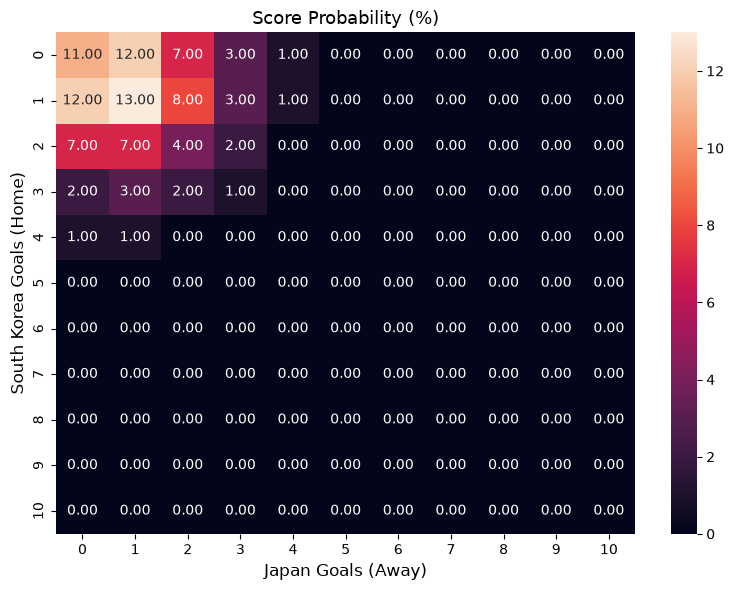

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    score_matrix_perc,
    annot=True, fmt='.2f',
    xticklabels=range(max_goals+1),
    yticklabels=range(max_goals+1),
    ax=ax
)

ax.set_xlabel(f"{team_away} Goals (Away)", fontsize=12)
ax.set_ylabel(f"{team_home} Goals (Home)", fontsize=12)
ax.set_title("Score Probability (%)", fontsize=13)

plt.tight_layout()
plt.show()

#### Top 10 Most Likely Score

In [44]:
scores = []

for i in range(max_goals + 1):
    for j in range(max_goals + 1):
        scores.append(
            {
                "Score": f"{i}–{j}",
                "Probability (%)": score_matrix_perc[i, j]
            }
        )

top5_most_likely_score = pd.DataFrame(scores).sort_values("Probability (%)", ascending=False).head(10)
top5_most_likely_score.index = range(1, 11)

In [45]:
top5_most_likely_score

,Score,Probability (%)
1,1–1,13.0
2,0–1,12.0
3,1–0,12.0
4,0–0,11.0
5,1–2,8.0
6,0–2,7.0
7,2–1,7.0
8,2–0,7.0
9,2–2,4.0
10,1–3,3.0


#### Home Team Goal Distribution

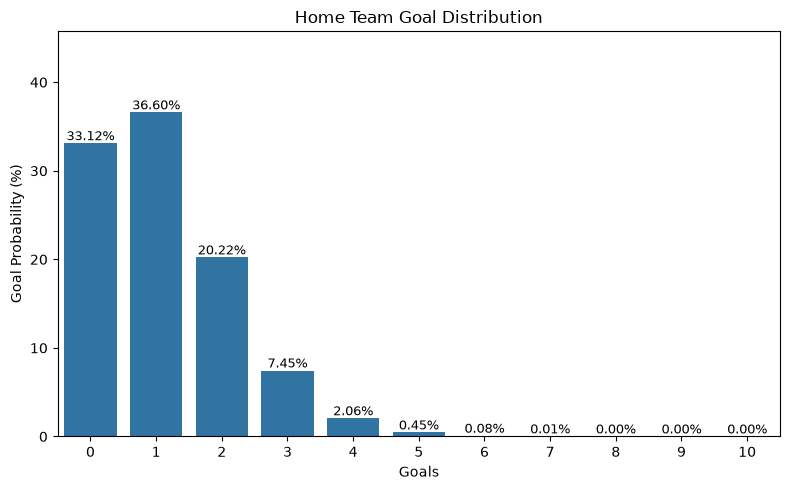

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

goals = np.arange(max_goals + 1)
goal_probs_perc = probs_home * 100

sns.barplot(
    x=goals,
    y=goal_probs_perc,
    ax=ax
)

ax.set_xlabel("Goals")
ax.set_ylabel("Goal Probability (%)")
ax.set_title("Home Team Goal Distribution")
ax.set_xticks(goals)
ax.set_ylim(0, goal_probs_perc.max() * 1.25)

for i, p in enumerate(goal_probs_perc):
    ax.text(i, p, f"{p:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Compute Win/Draw/Lose Probability

In [47]:
prob_home_win = np.sum(np.tril(score_matrix_perc, -1))   # home > away (below diagonal)
prob_draw     = np.sum(np.diag(score_matrix_perc))       # home == away (diagonal)
prob_away_win = np.sum(np.triu(score_matrix_perc, 1))    # away > home (above diagonal)

In [48]:
prob_home_win

np.float64(35.0)

In [49]:
prob_draw

np.float64(29.0)

In [50]:
prob_away_win

np.float64(37.0)

In [51]:
# find the index of the higest probability
score_matrix_perc.argmax()

np.int64(12)

In [52]:
# most likely exact score
idx = np.unravel_index(score_matrix_perc.argmax(), score_matrix_perc.shape)

In [53]:
idx

(np.int64(1), np.int64(1))

In [54]:
most_likely_score = (int(idx[0]), int(idx[1]))

In [55]:
most_likely_score

(1, 1)

In [56]:
final_result = {
    'score_matrix': score_matrix_perc,
    'prob_home_win': prob_home_win,
    'prob_draw': prob_draw,
    'prob_away_win': prob_away_win,
    'most_likely_score': most_likely_score
}

In [57]:
final_result

{'score_matrix': array([[11., 12.,  7.,  3.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [12., 13.,  8.,  3.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 7.,  7.,  4.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 2.,  3.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]]),
 'prob_home_win': np.float64(35.0),
 'prob_draw': np.float64(29.0),
 'prob_away_win': np.float64(37.0),
 'most_likely_score': (1, 1)}

In [58]:
most_likely_score = final_result["most_likely_score"]

print(f"{team_home} vs. {team_away}")
print("-" * 40)
print(f"Expected Goals    : {lambda_home:.2f} – {lambda_away:.2f}")
print(f"Most Likely Score : {most_likely_score[0]}–{most_likely_score[1]}")
print(f"Home Win          : {final_result['prob_home_win']:.0f}%")
print(f"Draw              : {final_result['prob_draw']:.0f}%")
print(f"Away Win          : {final_result['prob_away_win']:.0f}%")

South Korea vs. Japan
----------------------------------------
Expected Goals    : 1.11 – 1.12
Most Likely Score : 1–1
Home Win          : 35%
Draw              : 29%
Away Win          : 37%


## Save Predictor

In [59]:
predictor = {
    "team_feats": team_feats,
    "worldcup_ranks":  worldcup_ranks,
    "model": {
        "home": model_home,
        "away": model_away,
        "col_features": col_features
    }
}

In [60]:
with open("./intermediate/predictor.pickle", "wb") as fout:
    pickle.dump(predictor, file=fout)